# SPANet Prediction Evaluation: Five-Feature and B-Tag-Feature Models

This notebook reads prediction HDF5 files already produced by the Slurm GPU evaluation jobs and makes performance plots. It does not load checkpoints or run model inference.


In [1]:
import os

# Must be set before importing h5py/numpy/pandas/sklearn.
# Otherwise OpenBLAS may try to spawn one thread per visible CPU and kill the Jupyter kernel.
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')

from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

PREDICTION_FILES = {
  'baseline_5f_balanced': Path('/local/norman/UHHAnalysis/SPANet/predictions/260706_SPANet_22v1_anygpu_test23_predictions.h5'),
  'no_balance': Path('/local/norman/UHHAnalysis/SPANet/predictions/260731_spanet_lossscan_nobalance_test23_predictions.h5'),
  'hh_assign_1p25': Path('/local/norman/UHHAnalysis/SPANet/predictions/260803_spanet_lossscan_hhassign125_fp32_test23_predictions.h5'),
  'hh_assign_1p50': Path('/local/norman/UHHAnalysis/SPANet/predictions/260805_spanet_lossscan_hhassign150_fp32_test23_predictions.h5'),
  'btag_features_best': Path('/local/norman/UHHAnalysis/SPANet/predictions/260709_SPANet_22_23_v14_btag_features_best_test23_predictions.h5'),
  'btag_features_resume': Path('/local/norman/UHHAnalysis/SPANet/predictions/260709_SPANet_22_23_v14_btag_features_resume_best_test23_predictions.h5'),
}


# Held-out HDF5 used to create these test predictions.
# Needed for reco-only baseline comparisons from INPUTS/Source.
TRAINING_HDF5 = Path('/local/norman/UHHAnalysis/SPANet/hdf5/22_23_v14_vbf_signal_test_23only.h5')

PLOT_DIR = Path('/local/norman/UHHAnalysis/SPANet/plots/model_evaluation_all_models_test23')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

for name, path in PREDICTION_FILES.items():
    print(name, path, path.exists())
print('reference inputs:', TRAINING_HDF5, TRAINING_HDF5.exists())


baseline_5f_balanced /local/norman/UHHAnalysis/SPANet/predictions/260706_SPANet_22v1_anygpu_test23_predictions.h5 True
no_balance /local/norman/UHHAnalysis/SPANet/predictions/260731_spanet_lossscan_nobalance_test23_predictions.h5 True
hh_assign_1p25 /local/norman/UHHAnalysis/SPANet/predictions/260803_spanet_lossscan_hhassign125_fp32_test23_predictions.h5 True
hh_assign_1p50 /local/norman/UHHAnalysis/SPANet/predictions/260805_spanet_lossscan_hhassign150_fp32_test23_predictions.h5 True
btag_features_best /local/norman/UHHAnalysis/SPANet/predictions/260709_SPANet_22_23_v14_btag_features_best_test23_predictions.h5 True
btag_features_resume /local/norman/UHHAnalysis/SPANet/predictions/260709_SPANet_22_23_v14_btag_features_resume_best_test23_predictions.h5 True
reference inputs: /local/norman/UHHAnalysis/SPANet/hdf5/22_23_v14_vbf_signal_test_23only.h5 True


In [2]:
def load_prediction_file(path: Path) -> dict:
    results = {}
    with h5py.File(path, 'r') as f:
        results['num_jets'] = f['num_jets'][:]
        for target in f:
            if target == 'num_jets':
                continue
            results[target] = {key: f[target][key][:] for key in f[target]}
    return results

def available_targets(results: dict) -> list[str]:
    return [key for key in results if key != 'num_jets']

all_results = {name: load_prediction_file(path) for name, path in PREDICTION_FILES.items()}

for name, results in all_results.items():
    print(f'\n{name}')
    print('events:', len(results['num_jets']))
    print('targets:', available_targets(results))
    print('n_jets:', results['num_jets'].min(), '...', results['num_jets'].max())

def recompute_pair_correct(results: dict, target: str) -> np.ndarray:
    prediction = np.sort(results[target]['prediction'], axis=1)
    truth = np.sort(results[target]['target'], axis=1)
    return np.all(prediction == truth, axis=1)

def target_correct(results: dict, target: str) -> np.ndarray:
    # Stored prediction files can contain order-sensitive correctness flags.
    # HH->bb and VBF q/q are symmetric pairs, so recompute pair correctness here.
    return recompute_pair_correct(results, target)



baseline_5f_balanced
events: 785691
targets: ['higgs_bb', 'vbf']
n_jets: 2 ... 11

no_balance
events: 785691
targets: ['higgs_bb', 'vbf']
n_jets: 2 ... 11

hh_assign_1p25
events: 785691
targets: ['higgs_bb', 'vbf']
n_jets: 2 ... 11

hh_assign_1p50
events: 785691
targets: ['higgs_bb', 'vbf']
n_jets: 2 ... 11

btag_features_best
events: 785691
targets: ['higgs_bb', 'vbf']
n_jets: 2 ... 11

btag_features_resume
events: 785691
targets: ['higgs_bb', 'vbf']
n_jets: 2 ... 11


In [3]:
def roc_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan, None, None
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return auc(fpr, tpr), fpr, tpr

def summarize_results(results: dict) -> pd.DataFrame:
    rows = []
    targets = available_targets(results)
    both_present = np.ones(len(results['num_jets']), dtype=bool)
    both_correct = np.ones(len(results['num_jets']), dtype=bool)

    for target in targets:
        mask = results[target]['mask'].astype(bool)
        correct = target_correct(results, target)
        det = results[target]['detection_probability']
        score = results[target]['assignment_probability']

        both_present &= mask
        both_correct &= correct

        det_auc, _, _ = roc_auc(mask, det)
        assign_auc, _, _ = roc_auc(correct[mask], score[mask]) if mask.any() else (np.nan, None, None)

        rows.append({
            'target': target,
            'events': len(mask),
            'target_present': int(mask.sum()),
            'target_present_fraction': mask.mean(),
            'assignment_accuracy_on_present': correct[mask].mean() if mask.any() else np.nan,
            'detection_auc': det_auc,
            'assignment_score_auc_on_present': assign_auc,
            'mean_assignment_probability_present': score[mask].mean() if mask.any() else np.nan,
            'median_assignment_probability_present': np.median(score[mask]) if mask.any() else np.nan,
        })

    rows.append({
        'target': 'both_higgs_bb_and_vbf',
        'events': len(both_present),
        'target_present': int(both_present.sum()),
        'target_present_fraction': both_present.mean(),
        'assignment_accuracy_on_present': both_correct[both_present].mean() if both_present.any() else np.nan,
        'detection_auc': np.nan,
        'assignment_score_auc_on_present': np.nan,
        'mean_assignment_probability_present': np.nan,
        'median_assignment_probability_present': np.nan,
    })
    return pd.DataFrame(rows)

summary = pd.concat(
    [summarize_results(results).assign(run=name) for name, results in all_results.items()],
    ignore_index=True,
)
summary = summary[['run'] + [col for col in summary.columns if col != 'run']]
display(summary)
summary.to_csv(PLOT_DIR / 'test_summary.csv', index=False)


,run,target,events,target_present,target_present_fraction,assignment_accuracy_on_present,detection_auc,assignment_score_auc_on_present,mean_assignment_probability_present,median_assignment_probability_present
0,baseline_5f_balanced,higgs_bb,785691,494181,0.628976,0.939441,0.956599,0.987016,0.942900,0.999874
1,baseline_5f_balanced,vbf,785691,300122,0.381985,0.884933,0.943149,0.971706,0.878535,0.996206
2,baseline_5f_balanced,both_higgs_bb_and_vbf,785691,172785,0.219915,0.944046,NaN,NaN,NaN,NaN
3,no_balance,higgs_bb,785691,494181,0.628976,0.937035,0.958358,0.988313,0.937770,0.999880
4,no_balance,vbf,785691,300122,0.381985,0.882714,0.945597,0.975582,0.881448,0.997647
5,no_balance,both_higgs_bb_and_vbf,785691,172785,0.219915,0.947056,NaN,NaN,NaN,NaN
6,hh_assign_1p25,higgs_bb,785691,494181,0.628976,0.916399,0.946346,0.986209,0.915273,0.999315
7,hh_assign_1p25,vbf,785691,300122,0.381985,0.879282,0.936386,0.966723,0.871276,0.993883
8,hh_assign_1p25,both_higgs_bb_and_vbf,785691,172785,0.219915,0.932957,NaN,NaN,NaN,NaN
9,hh_assign_1p50,higgs_bb,785691,494181,0.628976,0.937159,0.961025,0.990454,0.938428,0.999921


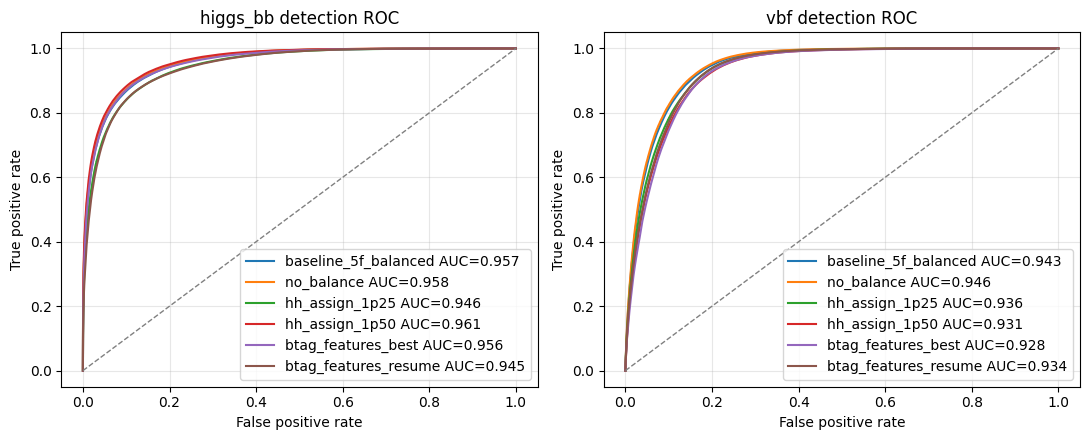

In [4]:
def plot_detection_rocs(all_results: dict):
    targets = available_targets(next(iter(all_results.values())))
    fig, axes = plt.subplots(1, len(targets), figsize=(5.5 * len(targets), 4.5))
    if len(targets) == 1:
        axes = [axes]

    for ax, target in zip(axes, targets):
        for run, results in all_results.items():
            mask = results[target]['mask'].astype(bool)
            score = results[target]['detection_probability']
            value, fpr, tpr = roc_auc(mask, score)
            if fpr is not None:
                ax.plot(fpr, tpr, label=f'{run} AUC={value:.3f}')
        ax.plot([0, 1], [0, 1], '--', color='0.5', linewidth=1)
        ax.set_title(f'{target} detection ROC')
        ax.set_xlabel('False positive rate')
        ax.set_ylabel('True positive rate')
        ax.grid(alpha=0.3)
        ax.legend()

    fig.tight_layout()
    fig.savefig(PLOT_DIR / 'detection_rocs.png', dpi=160)
    plt.show()

plot_detection_rocs(all_results)


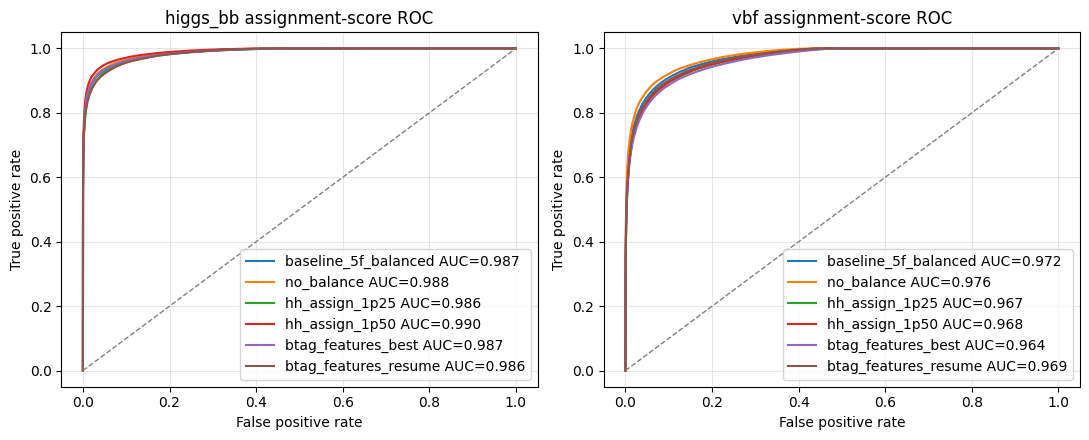

In [5]:
def plot_assignment_score_rocs(all_results: dict):
    targets = available_targets(next(iter(all_results.values())))
    fig, axes = plt.subplots(1, len(targets), figsize=(5.5 * len(targets), 4.5))
    if len(targets) == 1:
        axes = [axes]

    for ax, target in zip(axes, targets):
        for run, results in all_results.items():
            mask = results[target]['mask'].astype(bool)
            correct = target_correct(results, target)
            score = results[target]['assignment_probability']
            value, fpr, tpr = roc_auc(correct[mask], score[mask]) if mask.any() else (np.nan, None, None)
            if fpr is not None:
                ax.plot(fpr, tpr, label=f'{run} AUC={value:.3f}')
        ax.plot([0, 1], [0, 1], '--', color='0.5', linewidth=1)
        ax.set_title(f'{target} assignment-score ROC')
        ax.set_xlabel('False positive rate')
        ax.set_ylabel('True positive rate')
        ax.grid(alpha=0.3)
        ax.legend()

    fig.tight_layout()
    fig.savefig(PLOT_DIR / 'assignment_score_rocs.png', dpi=160)
    plt.show()

plot_assignment_score_rocs(all_results)


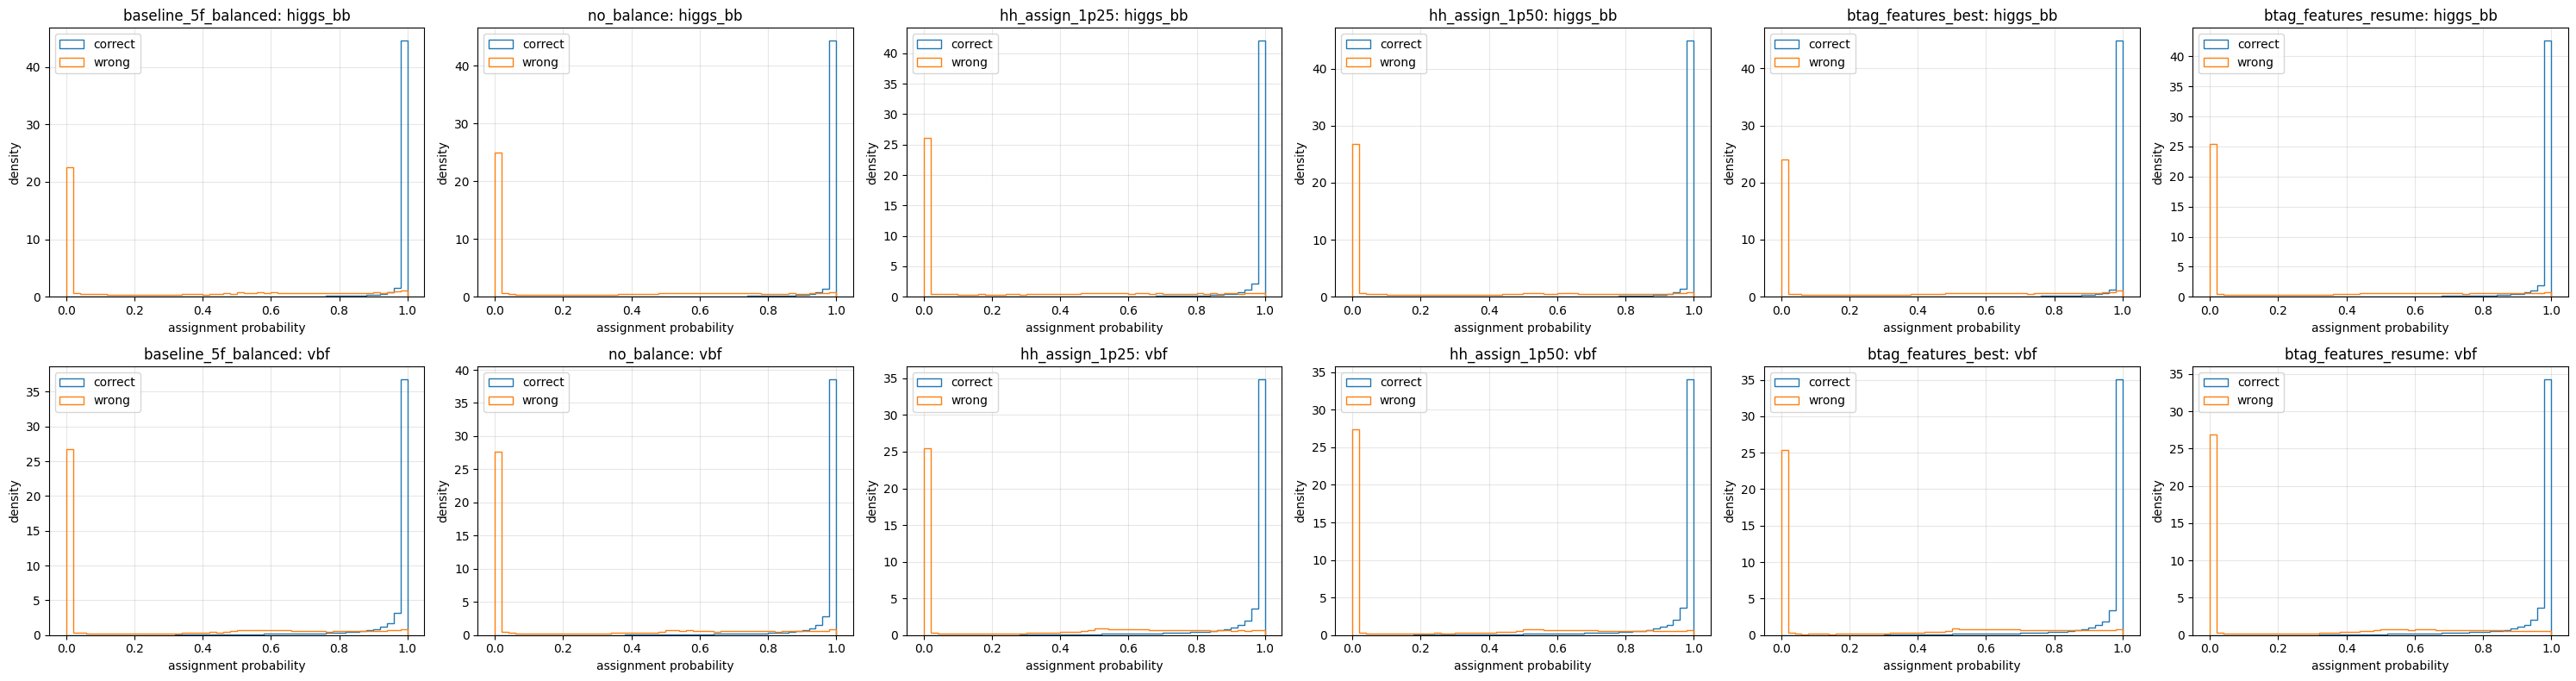

In [6]:
def plot_assignment_probability_histograms(all_results: dict):
    targets = available_targets(next(iter(all_results.values())))
    fig, axes = plt.subplots(len(targets), len(all_results), figsize=(5 * len(all_results), 4 * len(targets)), squeeze=False)

    for row, target in enumerate(targets):
        for col, (run, results) in enumerate(all_results.items()):
            ax = axes[row, col]
            mask = results[target]['mask'].astype(bool)
            correct = target_correct(results, target)
            score = results[target]['assignment_probability']

            ax.hist(score[mask & correct], bins=50, range=(0, 1), histtype='step', density=True, label='correct')
            ax.hist(score[mask & ~correct], bins=50, range=(0, 1), histtype='step', density=True, label='wrong')
            ax.set_title(f'{run}: {target}')
            ax.set_xlabel('assignment probability')
            ax.set_ylabel('density')
            ax.grid(alpha=0.3)
            ax.legend()

    fig.tight_layout()
    fig.savefig(PLOT_DIR / 'assignment_probability_histograms.png', dpi=160)
    plt.show()

plot_assignment_probability_histograms(all_results)


## Score Threshold Diagnostics

These plots show the usual assignment-model tradeoff between purity and efficiency as a function of the SPANet assignment probability. Purity is the fraction of selected assignments that are correct; efficiency is the fraction of all truth-present events that are selected and correct.


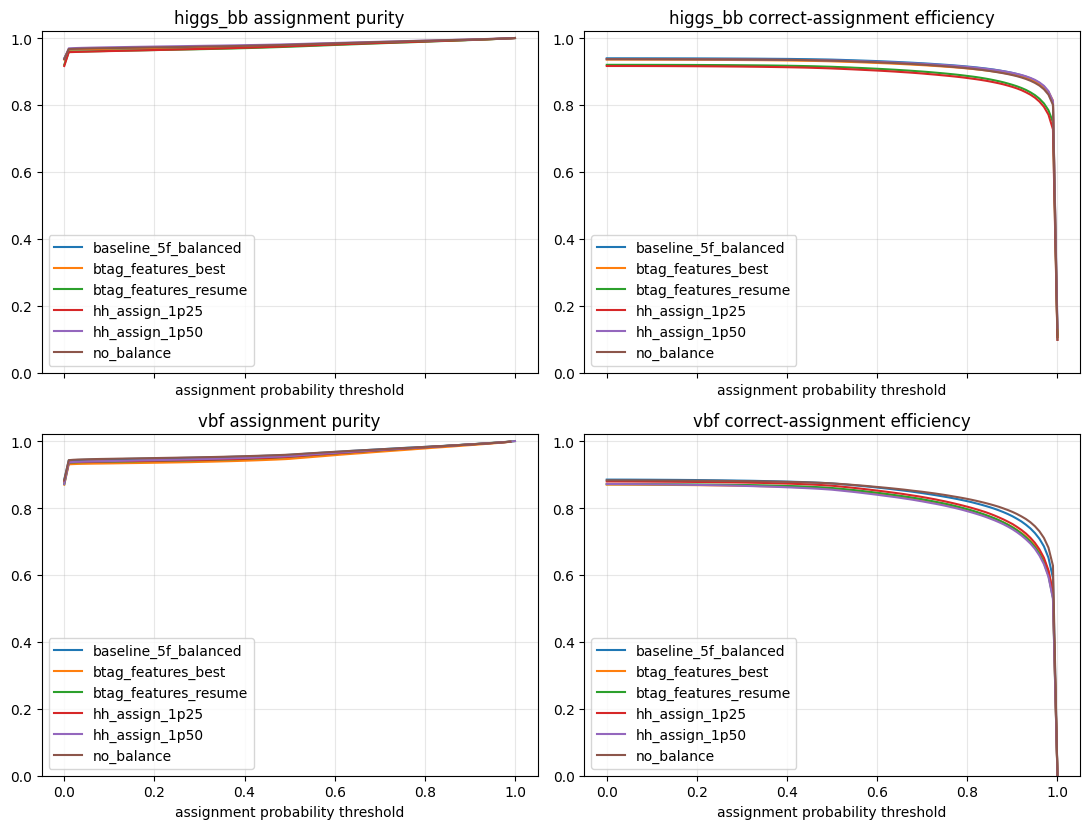

,run,target,threshold,selected_events,purity,efficiency,selection_fraction
50,baseline_5f_balanced,higgs_bb,0.50,472685,0.978026,0.935483,0.956502
80,baseline_5f_balanced,higgs_bb,0.80,456419,0.990463,0.914778,0.923587
90,baseline_5f_balanced,higgs_bb,0.90,445119,0.994462,0.895733,0.900721
99,baseline_5f_balanced,higgs_bb,0.99,398402,0.999094,0.805456,0.806186
151,baseline_5f_balanced,vbf,0.50,273365,0.958938,0.873445,0.910846
181,baseline_5f_balanced,vbf,0.80,250561,0.982687,0.820410,0.834864
191,baseline_5f_balanced,vbf,0.90,235052,0.990138,0.775465,0.783188
200,baseline_5f_balanced,vbf,0.99,177505,0.998473,0.590540,0.591443
252,no_balance,higgs_bb,0.50,470212,0.979809,0.932286,0.951498
282,no_balance,higgs_bb,0.80,453260,0.991828,0.909699,0.917194


In [7]:
def purity_efficiency_vs_score(results: dict, target: str, thresholds=None) -> pd.DataFrame:
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 101)

    mask = results[target]['mask'].astype(bool)
    correct = target_correct(results, target)
    score = results[target]['assignment_probability']

    rows = []
    denominator = mask.sum()
    for threshold in thresholds:
        selected = mask & (score >= threshold)
        selected_correct = selected & correct
        rows.append({
            'target': target,
            'threshold': threshold,
            'selected_events': int(selected.sum()),
            'purity': selected_correct.sum() / selected.sum() if selected.any() else np.nan,
            'efficiency': selected_correct.sum() / denominator if denominator else np.nan,
            'selection_fraction': selected.sum() / denominator if denominator else np.nan,
        })
    return pd.DataFrame(rows)

threshold_tables = []
for run, results in all_results.items():
    for target in available_targets(results):
        table = purity_efficiency_vs_score(results, target)
        table.insert(0, 'run', run)
        threshold_tables.append(table)
threshold_summary = pd.concat(threshold_tables, ignore_index=True)
threshold_summary.to_csv(PLOT_DIR / 'assignment_score_threshold_scan.csv', index=False)

def plot_threshold_curves(threshold_summary: pd.DataFrame):
    targets = threshold_summary['target'].unique()
    fig, axes = plt.subplots(len(targets), 2, figsize=(11, 4.2 * len(targets)), sharex=True)
    if len(targets) == 1:
        axes = np.array([axes])

    for row, target in enumerate(targets):
        df_target = threshold_summary[threshold_summary['target'] == target]
        for run, df in df_target.groupby('run'):
            axes[row, 0].plot(df['threshold'], df['purity'], label=run)
            axes[row, 1].plot(df['threshold'], df['efficiency'], label=run)
        axes[row, 0].set_title(f'{target} assignment purity')
        axes[row, 1].set_title(f'{target} correct-assignment efficiency')
        for ax in axes[row]:
            ax.set_xlabel('assignment probability threshold')
            ax.set_ylim(0, 1.02)
            ax.grid(alpha=0.3)
            ax.legend()

    fig.tight_layout()
    fig.savefig(PLOT_DIR / 'assignment_score_purity_efficiency.png', dpi=160)
    plt.show()

plot_threshold_curves(threshold_summary)
display(threshold_summary[threshold_summary['threshold'].isin([0.5, 0.8, 0.9, 0.95, 0.99])])


,run,target,n_jets,events,accuracy
0,baseline_5f_balanced,higgs_bb,2,48420,1.000000
1,baseline_5f_balanced,higgs_bb,3,176183,0.922183
2,baseline_5f_balanced,higgs_bb,4,186721,0.951671
3,baseline_5f_balanced,higgs_bb,5,63905,0.921149
4,baseline_5f_balanced,higgs_bb,6,15253,0.892480
...,...,...,...,...,...
115,btag_features_resume,vbf,7,2319,0.693834
116,btag_features_resume,vbf,8,409,0.635697
117,btag_features_resume,vbf,9,77,0.649351
118,btag_features_resume,vbf,10,9,0.777778


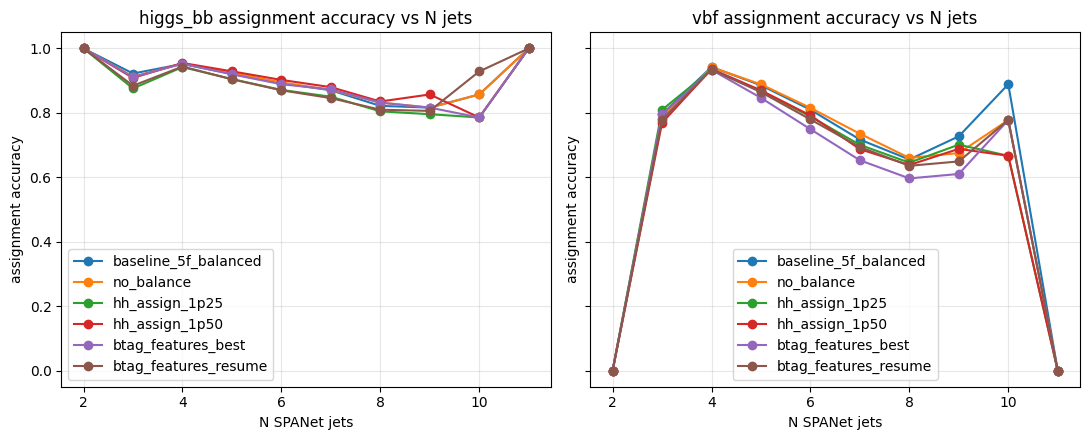

In [8]:
def accuracy_vs_njets(results: dict, run: str) -> pd.DataFrame:
    rows = []
    n_jets = results['num_jets']
    for target in available_targets(results):
        mask = results[target]['mask'].astype(bool)
        correct = target_correct(results, target)
        for n in np.unique(n_jets):
            sel = (n_jets == n) & mask
            if sel.sum() == 0:
                continue
            rows.append({
                'run': run,
                'target': target,
                'n_jets': int(n),
                'events': int(sel.sum()),
                'accuracy': correct[sel].mean(),
            })
    return pd.DataFrame(rows)

acc_njets = pd.concat([accuracy_vs_njets(results, run) for run, results in all_results.items()], ignore_index=True)
display(acc_njets)

targets = available_targets(next(iter(all_results.values())))
fig, axes = plt.subplots(1, len(targets), figsize=(5.5 * len(targets), 4.5), sharey=True)
if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    for run in all_results:
        df = acc_njets[(acc_njets['run'] == run) & (acc_njets['target'] == target)]
        ax.plot(df['n_jets'], df['accuracy'], marker='o', label=run)
    ax.set_title(f'{target} assignment accuracy vs N jets')
    ax.set_xlabel('N SPANet jets')
    ax.set_ylabel('assignment accuracy')
    ax.grid(alpha=0.3)
    ax.legend()

fig.tight_layout()
fig.savefig(PLOT_DIR / 'assignment_accuracy_vs_njets.png', dpi=160)
plt.show()


,n_jets,events,all_targets_accuracy,run
0,4,119801,0.985710,baseline_5f_balanced
1,5,41407,0.877460,baseline_5f_balanced
2,6,9420,0.773779,baseline_5f_balanced
3,7,1768,0.667986,baseline_5f_balanced
4,8,327,0.577982,baseline_5f_balanced
5,9,56,0.589286,baseline_5f_balanced
6,10,5,0.600000,baseline_5f_balanced
7,11,1,0.000000,baseline_5f_balanced
8,4,119801,0.986453,no_balance
9,5,41407,0.884150,no_balance


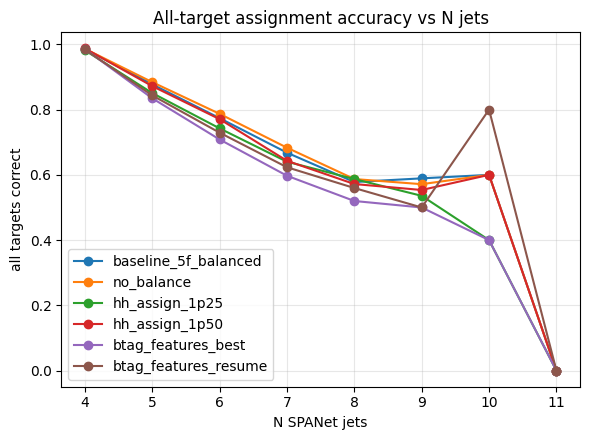

In [9]:
def event_level_accuracy(results: dict) -> pd.DataFrame:
    targets = available_targets(results)
    rows = []
    all_present = np.ones(len(results['num_jets']), dtype=bool)
    all_correct = np.ones(len(results['num_jets']), dtype=bool)
    for target in targets:
        all_present &= results[target]['mask'].astype(bool)
        all_correct &= target_correct(results, target)

    for n in np.unique(results['num_jets']):
        sel = (results['num_jets'] == n) & all_present
        if sel.sum() == 0:
            continue
        rows.append({
            'n_jets': int(n),
            'events': int(sel.sum()),
            'all_targets_accuracy': all_correct[sel].mean(),
        })
    return pd.DataFrame(rows)

event_tables = []
for run, results in all_results.items():
    table = event_level_accuracy(results)
    table['run'] = run
    event_tables.append(table)
event_acc = pd.concat(event_tables, ignore_index=True)
display(event_acc)

fig, ax = plt.subplots(figsize=(6, 4.5))
for run in all_results:
    df = event_acc[event_acc['run'] == run]
    ax.plot(df['n_jets'], df['all_targets_accuracy'], marker='o', label=run)
ax.set_title('All-target assignment accuracy vs N jets')
ax.set_xlabel('N SPANet jets')
ax.set_ylabel('all targets correct')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / 'event_assignment_accuracy_vs_njets.png', dpi=160)
plt.show()


## Label And Baseline Diagnostics

These checks help distinguish model limitations from label/evaluation problems. The baselines are intentionally simple reco-only assignments:

- HH-b baseline: two highest `btagDeepFlavB` jets.
- VBF baseline: jet pair with highest dijet mass, either using all jets or excluding the two highest-btag jets.
- Optional VBF tagger baseline: two highest `vbfjtag` jets, and the same after excluding the two highest-btag jets, when `vbfjtag` is available in the HDF5.


In [10]:
def target_validity_table(all_results):
    rows = []
    for run, results in all_results.items():
        n_jets = results['num_jets']
        for target in available_targets(results):
            mask = results[target]['mask'].astype(bool)
            truth = results[target]['target']
            pred = results[target]['prediction']
            target_valid = np.all((truth >= 0) & (truth < n_jets[:, None]), axis=1)
            pred_valid = np.all((pred >= 0) & (pred < n_jets[:, None]), axis=1)
            rows.append({
                'run': run,
                'target': target,
                'present': int(mask.sum()),
                'truth_valid_when_present': float(target_valid[mask].mean()) if mask.any() else np.nan,
                'pred_valid_when_present': float(pred_valid[mask].mean()) if mask.any() else np.nan,
                'invalid_truth_events': int((mask & ~target_valid).sum()),
                'invalid_pred_events': int((mask & ~pred_valid).sum()),
            })
    return pd.DataFrame(rows)

validity = target_validity_table(all_results)
display(validity)


,run,target,present,truth_valid_when_present,pred_valid_when_present,invalid_truth_events,invalid_pred_events
0,baseline_5f_balanced,higgs_bb,494181,1.0,1.00000,0,0
1,baseline_5f_balanced,vbf,300122,1.0,0.99253,0,2242
2,no_balance,higgs_bb,494181,1.0,1.00000,0,0
3,no_balance,vbf,300122,1.0,0.99253,0,2242
4,hh_assign_1p25,higgs_bb,494181,1.0,1.00000,0,0
5,hh_assign_1p25,vbf,300122,1.0,0.99253,0,2242
6,hh_assign_1p50,higgs_bb,494181,1.0,1.00000,0,0
7,hh_assign_1p50,vbf,300122,1.0,0.99253,0,2242
8,btag_features_best,higgs_bb,494181,1.0,1.00000,0,0
9,btag_features_best,vbf,300122,1.0,0.99253,0,2242


In [11]:
def overlap_table(all_results):
    rows = []
    for run, results in all_results.items():
        if not {'higgs_bb', 'vbf'}.issubset(results):
            continue
        h_mask = results['higgs_bb']['mask'].astype(bool)
        v_mask = results['vbf']['mask'].astype(bool)
        both = h_mask & v_mask
        h_truth = np.sort(results['higgs_bb']['target'], axis=1)
        v_truth = np.sort(results['vbf']['target'], axis=1)
        h_pred = np.sort(results['higgs_bb']['prediction'], axis=1)
        v_pred = np.sort(results['vbf']['prediction'], axis=1)

        truth_overlap = np.array([len(set(h).intersection(v)) > 0 for h, v in zip(h_truth, v_truth)])
        pred_overlap = np.array([len(set(h).intersection(v)) > 0 for h, v in zip(h_pred, v_pred)])

        rows.append({
            'run': run,
            'both_present': int(both.sum()),
            'truth_hbb_vbf_overlap_fraction': truth_overlap[both].mean() if both.any() else np.nan,
            'pred_hbb_vbf_overlap_fraction': pred_overlap[both].mean() if both.any() else np.nan,
            'truth_overlap_events': int((both & truth_overlap).sum()),
            'pred_overlap_events': int((both & pred_overlap).sum()),
        })
    return pd.DataFrame(rows)

overlap = overlap_table(all_results)
display(overlap)


,run,both_present,truth_hbb_vbf_overlap_fraction,pred_hbb_vbf_overlap_fraction,truth_overlap_events,pred_overlap_events
0,baseline_5f_balanced,172785,0.0,0.0,0,0
1,no_balance,172785,0.0,0.0,0,0
2,hh_assign_1p25,172785,0.0,0.0,0,0
3,hh_assign_1p50,172785,0.0,0.0,0,0
4,btag_features_best,172785,0.0,0.0,0,0
5,btag_features_resume,172785,0.0,0.0,0,0


In [12]:
def print_njet_examples(results, target='higgs_bb', n_jets_value=2, max_rows=20):
    n_jets = results['num_jets']
    mask = results[target]['mask'].astype(bool)
    truth = np.sort(results[target]['target'], axis=1)
    pred = np.sort(results[target]['prediction'], axis=1)
    correct = target_correct(results, target)
    score = results[target]['assignment_probability']

    sel = np.where((n_jets == n_jets_value) & mask)[0]
    rows = []
    for idx in sel[:max_rows]:
        rows.append({
            'event_index_in_prediction_file': int(idx),
            'n_jets': int(n_jets[idx]),
            'target': tuple(map(int, truth[idx])),
            'prediction': tuple(map(int, pred[idx])),
            'correct': bool(correct[idx]),
            'assignment_probability': float(score[idx]),
        })
    return pd.DataFrame(rows)

for run, results in all_results.items():
    print(f'\n{run}: hbb-present events with n_jets == 2')
    display(print_njet_examples(results, target='higgs_bb', n_jets_value=2, max_rows=20))



baseline_5f_balanced: hbb-present events with n_jets == 2


,event_index_in_prediction_file,n_jets,target,prediction,correct,assignment_probability
0,1,2,"(0, 1)","(0, 1)",True,1.0
1,4,2,"(0, 1)","(0, 1)",True,1.0
2,7,2,"(0, 1)","(0, 1)",True,1.0
3,16,2,"(0, 1)","(0, 1)",True,1.0
4,43,2,"(0, 1)","(0, 1)",True,1.0
5,48,2,"(0, 1)","(0, 1)",True,1.0
6,53,2,"(0, 1)","(0, 1)",True,1.0
7,64,2,"(0, 1)","(0, 1)",True,1.0
8,67,2,"(0, 1)","(0, 1)",True,1.0
9,73,2,"(0, 1)","(0, 1)",True,1.0



no_balance: hbb-present events with n_jets == 2


,event_index_in_prediction_file,n_jets,target,prediction,correct,assignment_probability
0,1,2,"(0, 1)","(0, 1)",True,1.0
1,4,2,"(0, 1)","(0, 1)",True,1.0
2,7,2,"(0, 1)","(0, 1)",True,1.0
3,16,2,"(0, 1)","(0, 1)",True,1.0
4,43,2,"(0, 1)","(0, 1)",True,1.0
5,48,2,"(0, 1)","(0, 1)",True,1.0
6,53,2,"(0, 1)","(0, 1)",True,1.0
7,64,2,"(0, 1)","(0, 1)",True,1.0
8,67,2,"(0, 1)","(0, 1)",True,1.0
9,73,2,"(0, 1)","(0, 1)",True,1.0



hh_assign_1p25: hbb-present events with n_jets == 2


...

,event_index_in_prediction_file,n_jets,target,prediction,correct,assignment_probability
0,1,2,"(0, 1)","(0, 1)",True,1.0
1,4,2,"(0, 1)","(0, 1)",True,1.0
2,7,2,"(0, 1)","(0, 1)",True,1.0
3,16,2,"(0, 1)","(0, 1)",True,1.0
4,43,2,"(0, 1)","(0, 1)",True,1.0
5,48,2,"(0, 1)","(0, 1)",True,1.0
6,53,2,"(0, 1)","(0, 1)",True,1.0
7,64,2,"(0, 1)","(0, 1)",True,1.0
8,67,2,"(0, 1)","(0, 1)",True,1.0
9,73,2,"(0, 1)","(0, 1)",True,1.0



btag_features_best: hbb-present events with n_jets == 2


,event_index_in_prediction_file,n_jets,target,prediction,correct,assignment_probability
0,1,2,"(0, 1)","(0, 1)",True,1.0
1,4,2,"(0, 1)","(0, 1)",True,1.0
2,7,2,"(0, 1)","(0, 1)",True,1.0
3,16,2,"(0, 1)","(0, 1)",True,1.0
4,43,2,"(0, 1)","(0, 1)",True,1.0
5,48,2,"(0, 1)","(0, 1)",True,1.0
6,53,2,"(0, 1)","(0, 1)",True,1.0
7,64,2,"(0, 1)","(0, 1)",True,1.0
8,67,2,"(0, 1)","(0, 1)",True,1.0
9,73,2,"(0, 1)","(0, 1)",True,1.0



btag_features_resume: hbb-present events with n_jets == 2


,event_index_in_prediction_file,n_jets,target,prediction,correct,assignment_probability
0,1,2,"(0, 1)","(0, 1)",True,1.0
1,4,2,"(0, 1)","(0, 1)",True,1.0
2,7,2,"(0, 1)","(0, 1)",True,1.0
3,16,2,"(0, 1)","(0, 1)",True,1.0
4,43,2,"(0, 1)","(0, 1)",True,1.0
5,48,2,"(0, 1)","(0, 1)",True,1.0
6,53,2,"(0, 1)","(0, 1)",True,1.0
7,64,2,"(0, 1)","(0, 1)",True,1.0
8,67,2,"(0, 1)","(0, 1)",True,1.0
9,73,2,"(0, 1)","(0, 1)",True,1.0


## VBF Two-Jet Diagnostic

This isolates events with a VBF target present and exactly two `SPANetJet` candidates. It checks whether HH-b is also present, what the truth/predicted pairs are, and whether the model is producing invalid VBF predictions because the two jets are already used by the HH-b branch.


In [13]:
def pair_tuple(array):
    return [tuple(map(int, row)) for row in array]

def vbf_two_jet_diagnostic(results: dict, max_rows: int = 30):
    n_jets = results['num_jets']
    h_mask = results['higgs_bb']['mask'].astype(bool)
    v_mask = results['vbf']['mask'].astype(bool)

    selection = v_mask & (n_jets == 2)
    indices = np.where(selection)[0]
    print(f'VBF-present events with n_jets == 2: {len(indices)}')
    if len(indices) == 0:
        return pd.DataFrame()

    h_correct = target_correct(results, 'higgs_bb')
    v_correct = target_correct(results, 'vbf')
    h_pred = results['higgs_bb']['prediction'][indices]
    v_pred = results['vbf']['prediction'][indices]
    h_target = results['higgs_bb']['target'][indices]
    v_target = results['vbf']['target'][indices]

    h_present = h_mask[indices]
    v_pred_valid = np.all(v_pred >= 0, axis=1)
    h_pred_valid = np.all(h_pred >= 0, axis=1)
    truth_overlap = np.array([
        bool(set(h_target[i].tolist()) & set(v_target[i].tolist()))
        if h_present[i] else False
        for i in range(len(indices))
    ])
    pred_overlap = np.array([
        bool(set(h_pred[i].tolist()) & set(v_pred[i].tolist()))
        if h_pred_valid[i] and v_pred_valid[i] else False
        for i in range(len(indices))
    ])

    summary = pd.DataFrame([
        {'quantity': 'events', 'value': len(indices)},
        {'quantity': 'hhb_present_fraction', 'value': h_present.mean()},
        {'quantity': 'hhb_present_events', 'value': int(h_present.sum())},
        {'quantity': 'vbf_pred_valid_fraction', 'value': v_pred_valid.mean()},
        {'quantity': 'vbf_invalid_pred_events', 'value': int((~v_pred_valid).sum())},
        {'quantity': 'hhb_pred_valid_fraction', 'value': h_pred_valid.mean()},
        {'quantity': 'truth_hhb_vbf_overlap_fraction_when_hhb_present', 'value': truth_overlap[h_present].mean() if h_present.any() else np.nan},
        {'quantity': 'pred_hhb_vbf_overlap_fraction_when_both_pred_valid', 'value': pred_overlap[(h_pred_valid & v_pred_valid)].mean() if (h_pred_valid & v_pred_valid).any() else np.nan},
        {'quantity': 'vbf_accuracy', 'value': v_correct[indices].mean()},
        {'quantity': 'hhb_accuracy_when_hhb_present', 'value': h_correct[indices][h_present].mean() if h_present.any() else np.nan},
    ])
    display(summary)

    rows = []
    for local, event_idx in enumerate(indices[:max_rows]):
        rows.append({
            'event_index_in_prediction_file': int(event_idx),
            'n_jets': int(n_jets[event_idx]),
            'hhb_present': bool(h_mask[event_idx]),
            'vbf_present': bool(v_mask[event_idx]),
            'hhb_target': tuple(map(int, results['higgs_bb']['target'][event_idx])),
            'vbf_target': tuple(map(int, results['vbf']['target'][event_idx])),
            'hhb_prediction': tuple(map(int, results['higgs_bb']['prediction'][event_idx])),
            'vbf_prediction': tuple(map(int, results['vbf']['prediction'][event_idx])),
            'hhb_correct': bool(h_correct[event_idx]) if h_mask[event_idx] else None,
            'vbf_correct': bool(v_correct[event_idx]),
            'hhb_assignment_probability': float(results['higgs_bb']['assignment_probability'][event_idx]),
            'vbf_assignment_probability': float(results['vbf']['assignment_probability'][event_idx]),
            'hhb_detection_probability': float(results['higgs_bb']['detection_probability'][event_idx]),
            'vbf_detection_probability': float(results['vbf']['detection_probability'][event_idx]),
        })
    examples = pd.DataFrame(rows)
    display(examples)
    examples.to_csv(PLOT_DIR / 'vbf_present_njets2_examples.csv', index=False)
    summary.to_csv(PLOT_DIR / 'vbf_present_njets2_summary.csv', index=False)
    return examples

for run, results in all_results.items():
    print('\n' + run)
    _ = vbf_two_jet_diagnostic(results, max_rows=40)



baseline_5f_balanced
VBF-present events with n_jets == 2: 2242


,quantity,value
0,events,2242.0
1,hhb_present_fraction,0.0
2,hhb_present_events,0.0
3,vbf_pred_valid_fraction,1.0
4,vbf_invalid_pred_events,0.0
5,hhb_pred_valid_fraction,1.0
6,truth_hhb_vbf_overlap_fraction_when_hhb_present,NaN
7,pred_hhb_vbf_overlap_fraction_when_both_pred_v...,0.0
8,vbf_accuracy,0.0
9,hhb_accuracy_when_hhb_present,NaN


,event_index_in_prediction_file,n_jets,hhb_present,vbf_present,hhb_target,vbf_target,hhb_prediction,vbf_prediction,hhb_correct,vbf_correct,hhb_assignment_probability,vbf_assignment_probability,hhb_detection_probability,vbf_detection_probability
0,1193,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.006096,0.062317
1,2375,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.000779,0.014954
2,2739,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.001461,0.223389
3,4619,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.005322,0.008125
4,4784,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.002035,0.172119
5,6715,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.002174,0.155151
6,6883,2,False,True,"(-1, -1)","(0, 1)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.001980,0.087280
7,7228,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.001490,0.186401
8,8215,2,False,True,"(-1, -1)","(0, 1)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.004200,0.405518
9,8643,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.003185,0.081360



no_balance
VBF-present events with n_jets == 2: 2242


,quantity,value
0,events,2242.0
1,hhb_present_fraction,0.0
2,hhb_present_events,0.0
3,vbf_pred_valid_fraction,1.0
4,vbf_invalid_pred_events,0.0
5,hhb_pred_valid_fraction,1.0
6,truth_hhb_vbf_overlap_fraction_when_hhb_present,NaN
7,pred_hhb_vbf_overlap_fraction_when_both_pred_v...,0.0
8,vbf_accuracy,0.0
9,hhb_accuracy_when_hhb_present,NaN


...

,quantity,value
0,events,2242.0
1,hhb_present_fraction,0.0
2,hhb_present_events,0.0
3,vbf_pred_valid_fraction,1.0
4,vbf_invalid_pred_events,0.0
5,hhb_pred_valid_fraction,1.0
6,truth_hhb_vbf_overlap_fraction_when_hhb_present,NaN
7,pred_hhb_vbf_overlap_fraction_when_both_pred_v...,0.0
8,vbf_accuracy,0.0
9,hhb_accuracy_when_hhb_present,NaN


,event_index_in_prediction_file,n_jets,hhb_present,vbf_present,hhb_target,vbf_target,hhb_prediction,vbf_prediction,hhb_correct,vbf_correct,hhb_assignment_probability,vbf_assignment_probability,hhb_detection_probability,vbf_detection_probability
0,1193,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.009972,0.057190
1,2375,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.002068,0.001265
2,2739,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.002663,0.193604
3,4619,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.004848,0.045776
4,4784,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.004383,0.054901
5,6715,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.001700,0.073669
6,6883,2,False,True,"(-1, -1)","(0, 1)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.002493,0.113159
7,7228,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.000929,0.180542
8,8215,2,False,True,"(-1, -1)","(0, 1)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.000762,0.708008
9,8643,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.004868,0.344727



btag_features_resume
VBF-present events with n_jets == 2: 2242


,quantity,value
0,events,2242.0
1,hhb_present_fraction,0.0
2,hhb_present_events,0.0
3,vbf_pred_valid_fraction,1.0
4,vbf_invalid_pred_events,0.0
5,hhb_pred_valid_fraction,1.0
6,truth_hhb_vbf_overlap_fraction_when_hhb_present,NaN
7,pred_hhb_vbf_overlap_fraction_when_both_pred_v...,0.0
8,vbf_accuracy,0.0
9,hhb_accuracy_when_hhb_present,NaN


,event_index_in_prediction_file,n_jets,hhb_present,vbf_present,hhb_target,vbf_target,hhb_prediction,vbf_prediction,hhb_correct,vbf_correct,hhb_assignment_probability,vbf_assignment_probability,hhb_detection_probability,vbf_detection_probability
0,1193,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.004150,0.060974
1,2375,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.000685,0.014839
2,2739,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.001416,0.263672
3,4619,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.010056,0.009743
4,4784,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.004757,0.139160
5,6715,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.000795,0.088501
6,6883,2,False,True,"(-1, -1)","(0, 1)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.004150,0.124756
7,7228,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.000762,0.179199
8,8215,2,False,True,"(-1, -1)","(0, 1)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.000849,0.685547
9,8643,2,False,True,"(-1, -1)","(1, 0)","(0, 1)","(2, 2)",None,False,1.0,0.0,0.004574,0.085693


In [14]:
def load_reference_inputs(training_hdf5: Path, n_reference_events: int) -> dict:
    with h5py.File(training_hdf5, 'r') as f:
        group = f['INPUTS']['Source']
        total = group['MASK'].shape[0]
        start = total - n_reference_events
        print('reading reference inputs:', start, '...', total - 1)
        return {key: group[key][start:total] for key in group.keys()}

reference_results = next(iter(all_results.values()))
inputs = load_reference_inputs(TRAINING_HDF5, len(reference_results['num_jets']))
print(inputs.keys())
print('input shape:', inputs['MASK'].shape)


reading reference inputs: 0 ... 785690
dict_keys(['MASK', 'btagDeepFlavB', 'btagDeepFlavCvB', 'btagDeepFlavCvL', 'btagDeepFlavQG', 'btagPNetB', 'btagPNetCvB', 'btagPNetCvL', 'btagPNetCvNotB', 'btagPNetQvG', 'btagPNetTauVJet', 'btagUParTAK4B', 'btagUParTAK4CvB', 'btagUParTAK4CvL', 'btagUParTAK4CvNotB', 'btagUParTAK4QvG', 'btagUParTAK4TauVJet', 'eta', 'hhbtag', 'mass', 'phi', 'pt', 'vbfjtag'])
input shape: (785691, 16)


In [15]:
def sorted_pair_equal(pair_a, pair_b):
    return np.all(np.sort(pair_a, axis=1) == np.sort(pair_b, axis=1), axis=1)

def top2_score_baseline(inputs, score_name, exclude_pair=None):
    mask = inputs['MASK'].astype(bool)
    score = np.where(mask, inputs[score_name], -np.inf)
    if exclude_pair is not None:
        rows = np.arange(score.shape[0])[:, None]
        valid_excluded = exclude_pair >= 0
        safe_exclude = np.where(valid_excluded, exclude_pair, 0)
        score[rows, safe_exclude] = np.where(valid_excluded, -np.inf, score[rows, safe_exclude])
    order = np.argsort(-score, axis=1)
    pair = order[:, :2]
    valid = np.isfinite(np.take_along_axis(score, pair, axis=1)).all(axis=1)
    pair[~valid] = -1
    return pair

def top2_btag_baseline(inputs):
    return top2_score_baseline(inputs, 'btagDeepFlavB')

def four_vector(pt, eta, phi, mass):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    energy = np.sqrt(np.maximum(px * px + py * py + pz * pz + mass * mass, 0.0))
    return energy, px, py, pz

def pair_mass(pt1, eta1, phi1, m1, pt2, eta2, phi2, m2):
    e1, px1, py1, pz1 = four_vector(pt1, eta1, phi1, m1)
    e2, px2, py2, pz2 = four_vector(pt2, eta2, phi2, m2)
    e = e1 + e2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    mass2 = e * e - px * px - py * py - pz * pz
    return np.sqrt(np.maximum(mass2, 0.0))

def max_mjj_baseline(inputs, exclude_pair=None):
    mask = inputs['MASK'].astype(bool)
    pt = inputs['pt']
    eta = inputs['eta']
    phi = inputs['phi']
    mass = inputs['mass']
    n_events, max_jets = mask.shape
    output = np.full((n_events, 2), -1, dtype=np.int64)

    for evt in range(n_events):
        valid = np.where(mask[evt])[0].tolist()
        if exclude_pair is not None:
            excluded = set(exclude_pair[evt].tolist())
            valid = [idx for idx in valid if idx not in excluded]
        if len(valid) < 2:
            continue

        best_pair = None
        best_mass = -np.inf
        for pos_i, i in enumerate(valid[:-1]):
            for j in valid[pos_i + 1:]:
                mjj = pair_mass(pt[evt, i], eta[evt, i], phi[evt, i], mass[evt, i],
                                pt[evt, j], eta[evt, j], phi[evt, j], mass[evt, j])
                if mjj > best_mass:
                    best_mass = mjj
                    best_pair = (i, j)
        output[evt] = best_pair
    return output

hbb_top2_btag = top2_btag_baseline(inputs)
vbf_max_mjj_all = max_mjj_baseline(inputs)
vbf_max_mjj_excl_top2_btag = max_mjj_baseline(inputs, exclude_pair=hbb_top2_btag)

vbf_top2_vbfjtag = None
vbf_top2_vbfjtag_excl_top2_btag = None
if 'vbfjtag' in inputs:
    vbf_top2_vbfjtag = top2_score_baseline(inputs, 'vbfjtag')
    vbf_top2_vbfjtag_excl_top2_btag = top2_score_baseline(inputs, 'vbfjtag', exclude_pair=hbb_top2_btag)
    print('Using vbfjtag baseline from INPUTS/Source/vbfjtag')
else:
    print('No INPUTS/Source/vbfjtag found. Recreate HDF5 with --extra-features vbfjtag to enable this baseline.')


Using vbfjtag baseline from INPUTS/Source/vbfjtag


In [16]:
def baseline_summary(results, hbb_pair, vbf_pair_all, vbf_pair_excl, vbf_pair_score=None, vbf_pair_score_excl=None):
    rows = []
    hmask = results['higgs_bb']['mask'].astype(bool)
    vmask = results['vbf']['mask'].astype(bool)
    htruth = results['higgs_bb']['target']
    vtruth = results['vbf']['target']

    hbb_correct = sorted_pair_equal(hbb_pair, htruth)
    vbf_all_valid = np.all(vbf_pair_all >= 0, axis=1)
    vbf_excl_valid = np.all(vbf_pair_excl >= 0, axis=1)
    vbf_all_correct = sorted_pair_equal(vbf_pair_all, vtruth)
    vbf_excl_correct = sorted_pair_equal(vbf_pair_excl, vtruth)

    rows.append({'baseline': 'higgs_bb_top2_btag', 'target': 'higgs_bb', 'events': int(hmask.sum()), 'accuracy': hbb_correct[hmask].mean()})
    rows.append({'baseline': 'vbf_max_mjj_all_jets', 'target': 'vbf', 'events': int((vmask & vbf_all_valid).sum()), 'accuracy': vbf_all_correct[vmask & vbf_all_valid].mean()})
    rows.append({'baseline': 'vbf_max_mjj_excluding_top2_btag', 'target': 'vbf', 'events': int((vmask & vbf_excl_valid).sum()), 'accuracy': vbf_excl_correct[vmask & vbf_excl_valid].mean()})

    both = hmask & vmask & vbf_excl_valid
    both_correct = hbb_correct & vbf_excl_correct
    rows.append({'baseline': 'top2_btag_plus_vbf_max_mjj_excl', 'target': 'both', 'events': int(both.sum()), 'accuracy': both_correct[both].mean() if both.any() else np.nan})

    if vbf_pair_score is not None:
        vbf_score_valid = np.all(vbf_pair_score >= 0, axis=1)
        vbf_score_correct = sorted_pair_equal(vbf_pair_score, vtruth)
        rows.append({'baseline': 'vbf_top2_vbfjtag', 'target': 'vbf', 'events': int((vmask & vbf_score_valid).sum()), 'accuracy': vbf_score_correct[vmask & vbf_score_valid].mean()})

    if vbf_pair_score_excl is not None:
        vbf_score_excl_valid = np.all(vbf_pair_score_excl >= 0, axis=1)
        vbf_score_excl_correct = sorted_pair_equal(vbf_pair_score_excl, vtruth)
        rows.append({'baseline': 'vbf_top2_vbfjtag_excluding_top2_btag', 'target': 'vbf', 'events': int((vmask & vbf_score_excl_valid).sum()), 'accuracy': vbf_score_excl_correct[vmask & vbf_score_excl_valid].mean()})

        both = hmask & vmask & vbf_score_excl_valid
        both_correct = hbb_correct & vbf_score_excl_correct
        rows.append({'baseline': 'top2_btag_plus_vbf_top2_vbfjtag_excl', 'target': 'both', 'events': int(both.sum()), 'accuracy': both_correct[both].mean() if both.any() else np.nan})

    return pd.DataFrame(rows)

# Baselines are independent of run because they use the same test events/labels.
baselines = baseline_summary(
    reference_results,
    hbb_top2_btag,
    vbf_max_mjj_all,
    vbf_max_mjj_excl_top2_btag,
    vbf_top2_vbfjtag,
    vbf_top2_vbfjtag_excl_top2_btag,
)
display(baselines)


,baseline,target,events,accuracy
0,higgs_bb_top2_btag,higgs_bb,494181,0.863477
1,vbf_max_mjj_all_jets,vbf,300122,0.789339
2,vbf_max_mjj_excluding_top2_btag,vbf,231209,0.721806
3,top2_btag_plus_vbf_max_mjj_excl,both,172785,0.773852
4,vbf_top2_vbfjtag,vbf,300122,0.739723
5,vbf_top2_vbfjtag_excluding_top2_btag,vbf,231209,0.732078
6,top2_btag_plus_vbf_top2_vbfjtag_excl,both,172785,0.793755


,method,target,accuracy
0,baseline_5f_balanced,higgs_bb,0.939441
1,baseline_5f_balanced,vbf,0.884933
2,baseline_5f_balanced,both,0.944046
3,no_balance,higgs_bb,0.937035
4,no_balance,vbf,0.882714
5,no_balance,both,0.947056
6,hh_assign_1p25,higgs_bb,0.916399
7,hh_assign_1p25,vbf,0.879282
8,hh_assign_1p25,both,0.932957
9,hh_assign_1p50,higgs_bb,0.937159


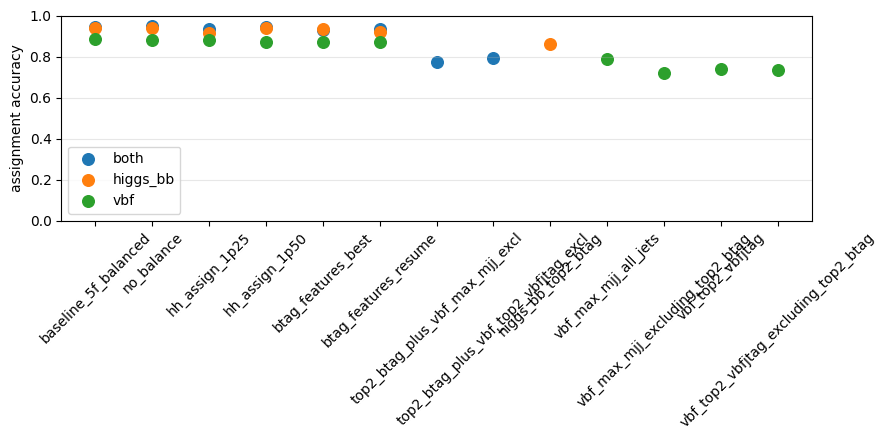

In [17]:
def compare_model_to_baselines(summary, baselines):
    rows = []
    for run in summary['run'].unique():
        for target in ['higgs_bb', 'vbf', 'both_higgs_bb_and_vbf']:
            row = summary[(summary['run'] == run) & (summary['target'] == target)].iloc[0]
            rows.append({
                'method': run,
                'target': target.replace('both_higgs_bb_and_vbf', 'both'),
                'accuracy': row['assignment_accuracy_on_present'],
            })
    for _, row in baselines.iterrows():
        rows.append({'method': row['baseline'], 'target': row['target'], 'accuracy': row['accuracy']})
    return pd.DataFrame(rows)

comparison = compare_model_to_baselines(summary, baselines)
display(comparison)

fig, ax = plt.subplots(figsize=(9, 4.5))
for target, df in comparison.groupby('target'):
    ax.scatter(df['method'], df['accuracy'], label=target, s=70)
ax.set_ylabel('assignment accuracy')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / 'model_vs_simple_baselines.png', dpi=160)
plt.show()


## Notes

- `detection_probability` measures whether a target system is present/labeled in the event.
- `assignment_probability` is the probability assigned to the selected jet assignment. Its ROC uses correct-vs-wrong assignment as the binary target among events where the target is present.
- The validation prediction files should correspond to the held-out validation split, not the full training HDF5. For final performance, produce prediction files for an independent test HDF5.
